In [1]:
import pandas as pd

df = pd.read_csv("./normalized_landmark_data_with_motion.csv")
X = df.drop(columns=["Video_Filename", "frame", "label"])  # 136D normalized features
y = df["label"]

X.head()
print(X.columns.tolist())

['norm_pt_0', 'norm_pt_1', 'norm_pt_2', 'norm_pt_3', 'norm_pt_4', 'norm_pt_5', 'norm_pt_6', 'norm_pt_7', 'norm_pt_8', 'norm_pt_9', 'norm_pt_10', 'norm_pt_11', 'norm_pt_12', 'norm_pt_13', 'norm_pt_14', 'norm_pt_15', 'norm_pt_16', 'norm_pt_17', 'norm_pt_18', 'norm_pt_19', 'norm_pt_20', 'norm_pt_21', 'norm_pt_22', 'norm_pt_23', 'norm_pt_24', 'norm_pt_25', 'norm_pt_26', 'norm_pt_27', 'norm_pt_28', 'norm_pt_29', 'norm_pt_30', 'norm_pt_31', 'norm_pt_32', 'norm_pt_33', 'norm_pt_34', 'norm_pt_35', 'norm_pt_36', 'norm_pt_37', 'norm_pt_38', 'norm_pt_39', 'norm_pt_40', 'norm_pt_41', 'norm_pt_42', 'norm_pt_43', 'norm_pt_44', 'norm_pt_45', 'norm_pt_46', 'norm_pt_47', 'norm_pt_48', 'norm_pt_49', 'norm_pt_50', 'norm_pt_51', 'norm_pt_52', 'norm_pt_53', 'norm_pt_54', 'norm_pt_55', 'norm_pt_56', 'norm_pt_57', 'norm_pt_58', 'norm_pt_59', 'norm_pt_60', 'norm_pt_61', 'norm_pt_62', 'norm_pt_63', 'norm_pt_64', 'norm_pt_65', 'norm_pt_66', 'norm_pt_67', 'norm_pt_68', 'norm_pt_69', 'norm_pt_70', 'norm_pt_71', '

In [2]:
#!pip install scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

y_pred = clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.8566433566433567
[[140  52]
 [ 30 350]]
              precision    recall  f1-score   support

           0       0.82      0.73      0.77       192
           1       0.87      0.92      0.90       380

    accuracy                           0.86       572
   macro avg       0.85      0.83      0.83       572
weighted avg       0.85      0.86      0.85       572



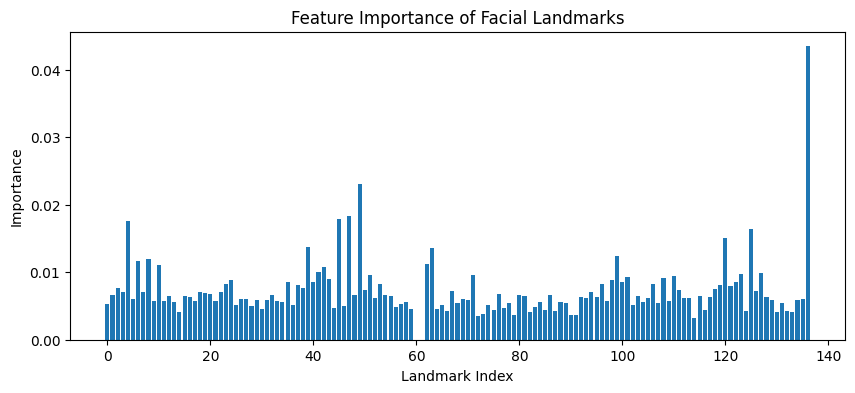

In [3]:
import matplotlib.pyplot as plt

importances = clf.feature_importances_
plt.figure(figsize=(10, 4))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance of Facial Landmarks")
plt.xlabel("Landmark Index")
plt.ylabel("Importance")
plt.show()


In [4]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = df.drop(columns=["Video_Filename", "frame", "label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[153  39]
 [ 13 367]]
              precision    recall  f1-score   support

           0       0.92      0.80      0.85       192
           1       0.90      0.97      0.93       380

    accuracy                           0.91       572
   macro avg       0.91      0.88      0.89       572
weighted avg       0.91      0.91      0.91       572



In [5]:
import joblib

joblib.dump(clf, "rf_face_model.pkl")
model.save_model("xgb_face_model.json")

Features from X: 137
Feature importances from model: 137
[0.0053295138058461755, 0.0066365708419500215, 0.007693615203106165, 0.007107258436009477, 0.017509257911650207, 0.006045609065954607, 0.011698070269231147, 0.007078941735233835, 0.01193166287828247, 0.005692077402461153, 0.011005121292588278, 0.005793912739454859, 0.006518800237275955, 0.005630769161240694, 0.0041533364158035995, 0.006413291452901554, 0.006399785729649446, 0.005677260685678543, 0.007070417334778897, 0.0069299185292286914, 0.006777226241779637, 0.005747992314172077, 0.00705666591244719, 0.00831524046685045, 0.008780736193414266, 0.005140598269449258, 0.006019198565071489, 0.006058663824875972, 0.004939681388773215, 0.005854637105188921, 0.004593334356602008, 0.005909960053814267, 0.006670408648523173, 0.005685963177978065, 0.00556185147633821, 0.008611707674267118, 0.005174640390691344, 0.008068116346754419, 0.007610830034433881, 0.013673739647829619, 0.00854634990610813, 0.01005226157267063, 0.010826881759784746

C:\Users\connellj2\AppData\Local\Temp\ipykernel_23796\1581235914.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20.values, y=top_20.index, palette="viridis")


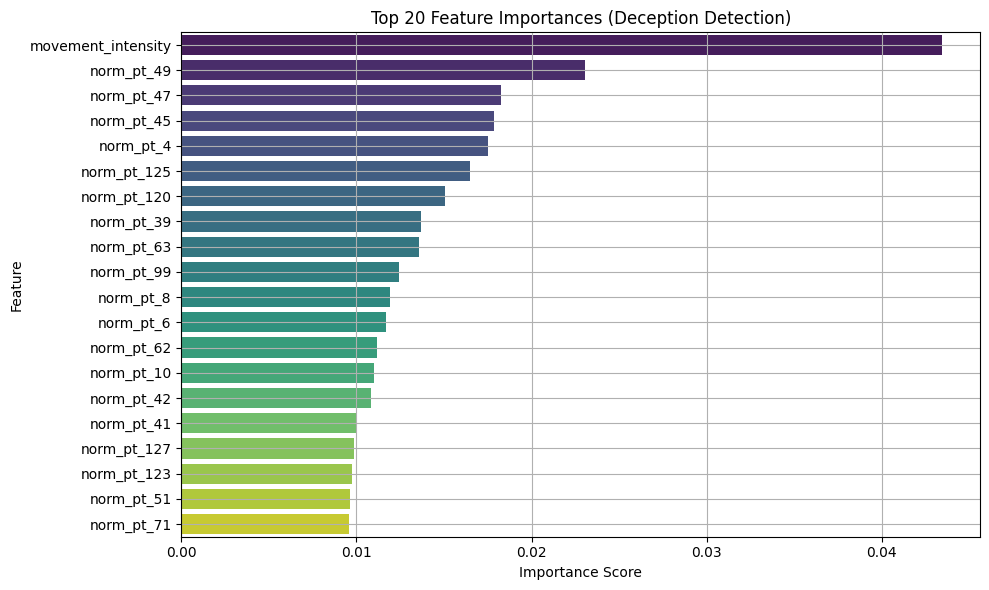

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Features from X:", len(X.columns))
print("Feature importances from model:", len(clf.feature_importances_))

print(clf.feature_importances_.tolist())


# Extract top 20 features
feat_importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_20 = feat_importance.head(20)

# Plot them
plt.figure(figsize=(10,6))
sns.barplot(x=top_20.values, y=top_20.index, palette="viridis")
plt.title("Top 20 Feature Importances (Deception Detection)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.grid(True)
plt.show()


In [7]:
feat_importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
motion_rank = feat_importance.index.get_loc("movement_intensity") + 1  # zero-based index → 1-based rank
print(f"📦 'movement_intensity' ranks #{motion_rank} in feature importance.")


📦 'movement_intensity' ranks #1 in feature importance.
